In [ ]:
from google import genai
client = genai.Client()
model = "gemini-flash-lite-latest"

In [ ]:
# Test gemini
try:
    response = client.models.generate_content(
        model=model,
        contents="Invent an original joke that non-English speakers could understand"
        # contents="תמציא בדיחה מקורית"
    )
    print(response.text)
except genai.errors.ServerError as err:
    print(f"Model {model} error: {err}")

To make a joke understandable across languages, it needs to rely on **universal human behavior** (the "rule of three" or a simple physical situation) rather than wordplay or idioms.

Here is an original "universal" joke:

***

**The Professional and the Cat**

A man walks into a job interview.

The interviewer asks, "What is your greatest strength?"
The man says, "I can answer any question immediately."

The interviewer smiles and asks, "What is 1,245 times 782?"
The man says, "Cat."

The interviewer looks confused. "That’s not even close! That’s completely wrong!"

The man replies, "Yes, but it was immediate."

***

### Why this works for non-English speakers:
1. **No puns:** It doesn't rely on double meanings of English words.
2. **Universal logic:** Everyone understands the concept of a "job interview" and the expectation of being "correct" vs. being "fast."
3. **Visual comedy:** The absurdity of the answer "Cat" is funny in any culture, regardless of the language.


In [17]:
import json, logging
import networkx as nx
logger = logging.getLogger("gemini")

In [5]:
def text_to_utilities(natural_languate_description:str)->dict:
    """
    This function uses AI to extract reasonable utility values 
    from a natural-language description of preferences.
    """
    contents = f"""
        הנה תיאור של העדפות בין שלוש משמרות: בוקר, צהריים וערב. 
        לפי התיאור המילולי, עליך לתת לכל משמרת ערך מספרי כלשהו בין 0 ל-100 המתאר את רמת ההעדפה.
        תחזיר את התשובה בפורמט JSON בתוך סוגריים מסולסלים בלי שום תוספות.
        ---
        '{natural_languate_description}'
        """
    try:
        response = client.models.generate_content(
            model=model,
            contents=contents
        )
        logger.debug("Response text: %s", response.text)
        utils = json.loads(response.text) 
        logger.debug("Response struct: %s", utils)
        return utils
    except genai.errors.ServerError as err:
        logger.error(f"Model {model} error: {err}")


In [ ]:
logger.handlers = [logging.StreamHandler()]
logger.setLevel(logging.DEBUG)

In [ ]:
# Test text_to_utilities
utils1 = text_to_utilities("בבוקר מאד לא נוח לי. בצהריים אפשרי. בערב הכי נוח.")
print(utils1)

Response text: {
  "בוקר": 10,
  "צהריים": 50,
  "ערב": 100
}
Response text: {
  "בוקר": 10,
  "צהריים": 50,
  "ערב": 100
}
Response struct: {'בוקר': 10, 'צהריים': 50, 'ערב': 100}
Response struct: {'בוקר': 10, 'צהריים': 50, 'ערב': 100}


{'בוקר': 10, 'צהריים': 50, 'ערב': 100}


In [9]:
utils = dict()
utils["אבי"] = utils1
utils["בני"] = text_to_utilities("בבוקר אידיאלי. בצהריים בסדר. בערב הכי פחות טוב.")
utils["גדי"] = text_to_utilities("הכי מתאים לי בצהריים. בוקר גם בסדר. ערב ככה ככה.")
print(utils)

Response text: {
  "בוקר": 100,
  "צהריים": 50,
  "ערב": 0
}
Response struct: {'בוקר': 100, 'צהריים': 50, 'ערב': 0}
Response text: {
  "בוקר": 70,
  "צהריים": 100,
  "ערב": 40
}
Response struct: {'בוקר': 70, 'צהריים': 100, 'ערב': 40}


{'אבי': {'בוקר': 10, 'צהריים': 50, 'ערב': 100}, 'בני': {'בוקר': 100, 'צהריים': 50, 'ערב': 0}, 'גדי': {'בוקר': 70, 'צהריים': 100, 'ערב': 40}}


In [11]:
def dicts_to_graph(map_person_to_utility_dict: dict[dict])->nx.Graph:
    """
    Generates a weighted bipartite graph that describes the utilities people assign to objects.

    >>> G = dicts_to_graph({"avi":{"x":50,"y":70}, "beni":{"x":30,"y":40}})
    >>> list(G.edges)
    [('avi', 'x'), ('avi', 'y'), ('x', 'beni'), ('y', 'beni')]
    """
    result = nx.Graph()
    for person,map_object_to_utility in map_person_to_utility_dict.items():
        for object,utility in map_object_to_utility.items():
            result.add_edge(person, object, weight=utility)
    return result

G = dicts_to_graph(utils)
print(list(G.edges))

[('אבי', 'בוקר'), ('אבי', 'צהריים'), ('אבי', 'ערב'), ('בוקר', 'בני'), ('בוקר', 'גדי'), ('צהריים', 'בני'), ('צהריים', 'גדי'), ('ערב', 'בני'), ('ערב', 'גדי')]


In [13]:
draw_options = {
    "font_size": 10,
    "node_size": 700,
    "node_color": "yellow",
    "edgecolors": "black",
    "linewidths": 1,
    "width": 1,
    "with_labels": True
}

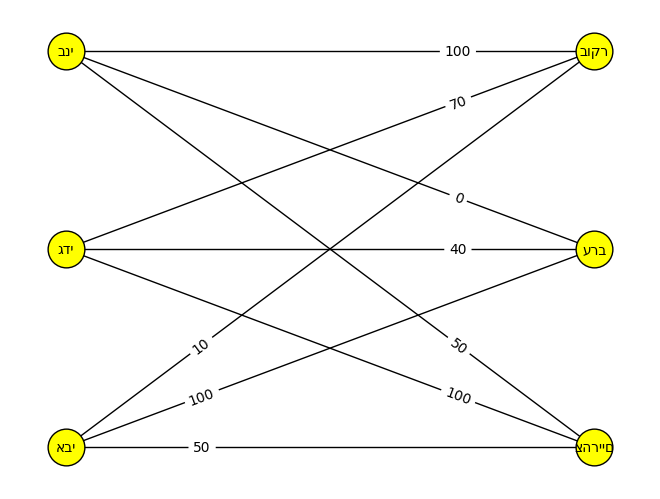

In [15]:
layout = nx.bipartite_layout(G, utils.keys())
nx.draw(G,  **draw_options, pos=layout)
nx.draw_networkx_edge_labels(G, layout, edge_labels=nx.get_edge_attributes(G,'weight'), label_pos=0.25);

In [16]:
max_weight_matching = nx.max_weight_matching(G) 
print(max_weight_matching)
# max_weight_matching_graph = nx.Graph(max_weight_matching)
# nx.draw(max_weight_matching_graph,  **draw_options, pos=layout)
# nx.draw_networkx_edge_labels(max_weight_matching_graph, layout, edge_labels=nx.get_edge_attributes(my_graph,'weight'));

{('גדי', 'צהריים'), ('בני', 'בוקר'), ('ערב', 'אבי')}
